# Advanced Presentation - matplotlib.animation
- David Gold and Quinn Robnett

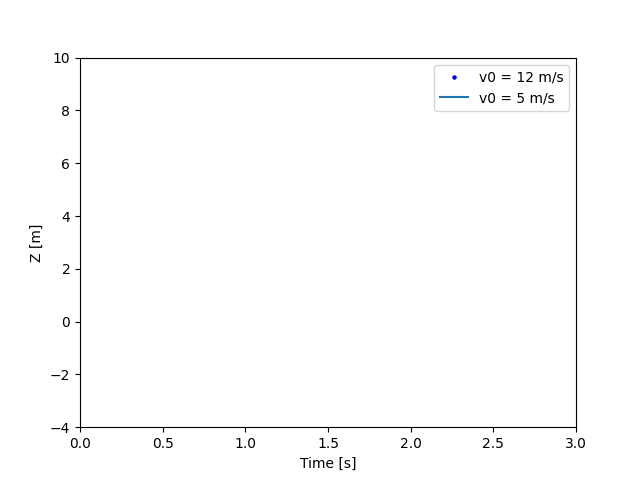

### What is matplotlib animation?
Maplotlib animation is a submodule of matplotlib which can enhance plots by making them animated. This package is not part of the standard Python library but can be imported using ```import matplotlib.animation as animation```.



There are two different function that are usrd to animate plots: ```FuncAnitmation``` and ```ArtistAnimation```.

```FuncAnimation``` generates data for the first frame of the animation, and then modifies it for each subsequent frame. ```ArtistAnimation``` takes in a list of plots and iterates through them to create the animation. Each one has it's own advantages and disadvatages. ```FuncAnimation``` is more efficient in memory and speed, but ```ArtistAnimation`` is more flexible with what you can animate.

### FuncAnimation

```FuncAnimation``` works by passing in a function that iteravely changes the data in a plot. There are 4 main steps do acheive this:

1. Plot the initial figure
2. Create a function that updates the data of a plot using one of many ```set_*``` methods
3. Call ```FuncAnimation```, passing in your function
4. Save or show animation

They key arguments for ```FuncAnimtation``` are:

1. ```fig``` - the figure used for the first frame
2. ```func``` - the function created to update data
3. ```frames``` - number of frames in the animation
4. ```interval``` - time between frames in ms

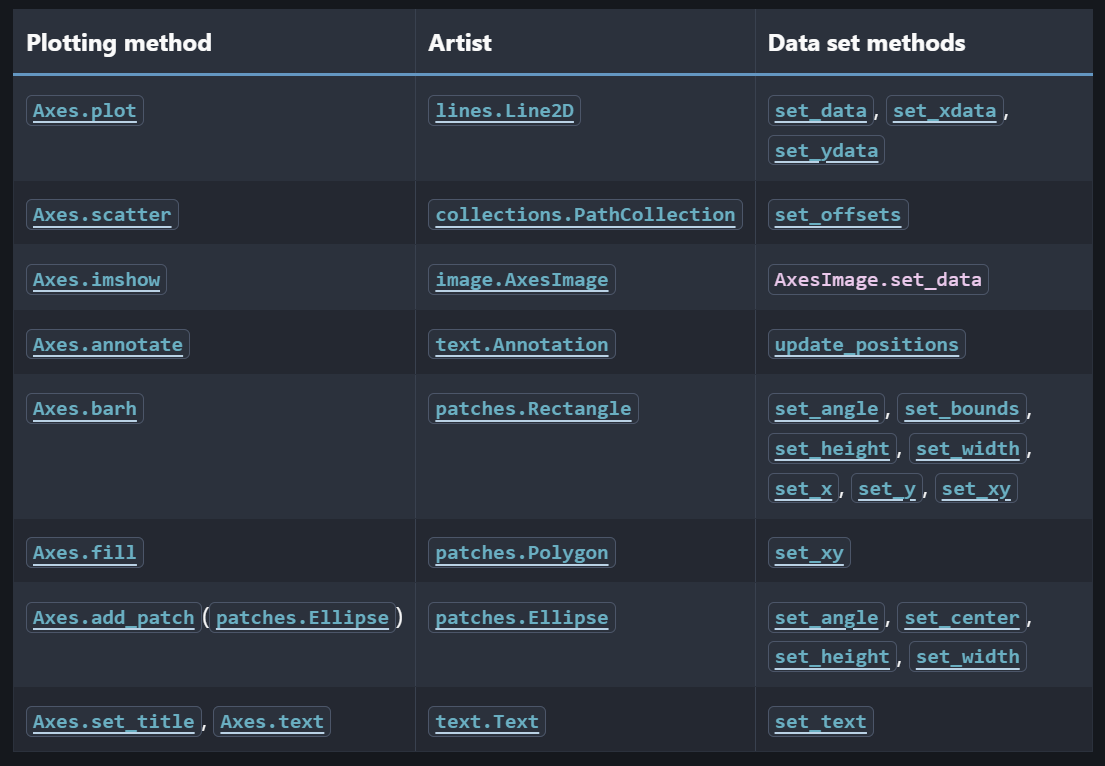

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation #import animation
from IPython.display import HTML #package to display animation in Google Colab

# Create figure and axis
fig, ax = plt.subplots()
t = np.linspace(0, 6, 80)
z = np.cos(t)
z2 = np.sin(t)

scat = ax.scatter(t[0], z[0], c="b", s=5, label='Cosine')
line2 = ax.plot(t[0], z2[0], label='Sine')[0]
ax.set(xlim=[0, 6], ylim=[-1.2, 1.2], xlabel='x', ylabel='y')
ax.legend()


def update(frame):
    # for each frame, update the data stored on each artist.
    x = t[:frame]
    y = z[:frame]
    # update the scatter plot:
    data = np.stack([x, y]).T
    scat.set_offsets(data)
    # update the line plot:
    line2.set_xdata(t[:frame])
    line2.set_ydata(z2[:frame])
    return (scat, line2)


ani = animation.FuncAnimation(fig=fig, func=update, frames=80, interval=60)
plt.close(fig)
# ani.save('/content/drive/MyDrive/velo.gif', writer='pillow')
HTML(ani.to_jshtml())

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# create sample profit data
data = {
    'day': list(range(1, 21)),
    'profit': [100, 50, 30, 25, -60, 20, -90, -80, -70, 40, 20, 10, 50, -30, 40, 30, -20, -80, -50, 150]
}
df = pd.DataFrame(data)

df['cumulative_profit'] = df['profit'].cumsum()

# Create figure and axis
fig, ax = plt.subplots()
ax.set(xlim=[df['day'].min(), df['day'].max()], ylim=[df['cumulative_profit'].min() - 50, df['cumulative_profit'].max() + 50])
ax.set_xlabel('Day')
ax.set_ylabel('Cumulative Profit')
ax.set_title('Cumulative Profit Over Time')
subtitle_text = ax.text(0.5, 0.95, '', ha='center', va='top', transform=ax.transAxes, fontsize=12)

# Initialize the line plot
line, = ax.plot([], [], lw=2)
ax.axhline(0, color='black', linewidth=1)

# Update function for animation
def update(frame):

    x = df['day'][:frame + 1] #set x variable for next frame
    y = df['cumulative_profit'][:frame + 1] #set y variable for next frame

    # Set the data for the line plot
    line.set_data(x, y)
    cumul = df['cumulative_profit'].iloc[frame]
    # Change the color based on the cumulative profit at the last point
    if cumul > 0:
        line.set_color('green')
    else:
        line.set_color('red')

    subtitle_text.set_text(f'{cumul:.2f}')
    subtitle_text.set_color('green' if cumul > 0 else 'red')

    return line, subtitle_text

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(df), interval=250, blit=True)

# Display the animation
plt.close(fig)  # To prevent a blank plot from showing
HTML(ani.to_jshtml())


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML


df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/wayne_ovi.csv')  # read csv

# calculate cumulative goals
df['ovi_cumul'] = df['Ovechkin'].cumsum()
df['wayne_cumul'] = df['Gretzky'].cumsum()

# initialize plot
fig, ax = plt.subplots()
ax.set_xlim(0, len(df)) #set x limits
max_goals = max(df['ovi_cumul'].max(), df['wayne_cumul'].max())
ax.set_ylim(0, max_goals + 2) #set y limits
ax.set_xlabel('Game Number') #x axis label
ax.set_ylabel('Cumulative Goals') #y axis label
ax.set_title('Cumulative Goal Totals by Game') #title
line1, = ax.plot([], [], label='Ovechkin', color='blue') #initialize first line
line2, = ax.plot([], [], label='Gretzky', color='orange') #initialize second line
ax.legend(loc='upper left') #legend location
subtitle1 = ax.text(0.49, 0.9, "", ha='right', va='bottom', transform=ax.transAxes, color='blue', fontsize=11) #subtitles
subtitle2 = ax.text(0.52, 0.9, "", ha='left', va='bottom', transform=ax.transAxes, color='orange', fontsize=11)

frame_indices = list(range(0, len(df), 10))  # Every 10th game
if frame_indices[-1] != len(df)-1:
    frame_indices.append(len(df)-1)

def update(frame):
    x = df['Game'][:frame+1] #update x data
    y1 = df['ovi_cumul'][:frame+1] #update y data for line 1
    y2 = df['wayne_cumul'][:frame+1] #update y data for line 2
    line1.set_data(x, y1) #set data
    line2.set_data(x, y2)

    goals1 = y1[frame] if frame > 0 else 0
    goals2 = y2[frame] if frame > 0 else 0

    subtitle1.set_text(f"Ovechkin: {goals1:.0f}") #updata subtitles
    subtitle2.set_text(f"Gretzky: {goals2:.0f}")

    return line1, line2, subtitle1, subtitle2

# Create animation
ani = animation.FuncAnimation(fig, update, frames=frame_indices, interval=50)

# Prevent static plot from showing
plt.close()

# Display in notebook
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

### ArtistAnimation

```ArtistAnimation``` creates an animation by taking in a fixed list of artists (plots), converting them into a frame-by-frame animation. Here are some of the key arguments:

1. ```fig```: The area in which the ArtistAnimation object will be drawn in
2. ```artists```: A list of artist objects that will be used in specified frames
3. ```interval```: The delay, or time elapsed between frames (in milliseconds)
repeat: A boolean indicator of whether or not the animation will restart after completion
   - Essentially a yes/no for if the animation will be a loop or remain static afterwards
4. ```repeat_delay```: If repeat is listed as TRUE, this acts the same as the interval parameter, but in terms of delay between the end of the animation and the start of it being repeated
5. ```blit```: A boolean indicator of whether or not blitting is used to optimize the drawing
    - Blitting involves only redrawing the parts of the plot that have changed between frames, rather than redrawing the entire plot


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

fig = plt.figure()

def f(x, y):
    return np.sin(x) + np.cos(y)

x = np.linspace(0, 2 * np.pi, 120)
y = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)

#Creating a list of articles
ims = []
for i in range(60):
    x += np.pi / 15.
    y += np.pi / 20.
    im = plt.imshow(f(x, y), animated=True)
    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000)

ani.save('dynamic_images.gif') #Saving the animation in the working directory

plt.close(fig)
HTML(ani.to_jshtml())



Output hidden; open in https://colab.research.google.com to view.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

#Setting the number of frames in the animation
frames = 20

#Puck Coordinates: np.linspace(starting coord, ending coord, frames between coords)
puck_x = np.concatenate([
    np.linspace(30, 40, frames // 3), #Pass #1
    np.linspace(40, 60, frames // 3), #Pass #2
    np.full(frames - 2*(frames // 3), 60) #Puck stays with the third player the rest of the animation
])

puck_y = np.concatenate([
    np.linspace(10, 20, frames // 3),
    np.linspace(20, 25, frames // 3),
    np.full(frames - 2*(frames // 3), 25)
])

#Blue Team Skaters
blue1_x = np.linspace(30, 35, frames)
blue1_y = np.linspace(10, 12, frames)

blue2_x = np.linspace(40, 45, frames)
blue2_y = np.linspace(20, 22, frames)

blue3_x = np.linspace(60, 62, frames)
blue3_y = np.linspace(25, 27, frames)

# Red Team Skaters
red1_x = np.linspace(50, 48, frames)
red1_y = np.linspace(10, 12, frames)

red2_x = np.linspace(55, 53, frames)
red2_y = np.linspace(20, 21, frames)

red3_x = np.linspace(45, 43, frames)
red3_y = np.linspace(30, 29, frames)

#Setting up the figure that holds the animation
fig, ax = plt.subplots()
ax.set_xlim(0, 100) #Rink Dimensions
ax.set_ylim(0, 42.5)
ax.set_aspect('equal') #Keeping the x and y scales equal (aspect ratio)
ax.set_title("Hockey Passing Play") #Creating a title for the viz

#Initializing a list to hold all animation frames
ims = []

#Loop of each frame in the animation
for i in range(frames):
    frame = []

    #Creating the puck as a black circle (k = black, o = circle)
    frame += ax.plot(puck_x[i], puck_y[i], 'ko', markersize=5)

    #Creating the blue team skaters as blue circles (b = blue, o = circle)
    frame += ax.plot(blue1_x[i], blue1_y[i], 'bo', markersize=10)
    frame += ax.plot(blue2_x[i], blue2_y[i], 'bo', markersize=10)
    frame += ax.plot(blue3_x[i], blue3_y[i], 'bo', markersize=10)

    #Creating the red team skaters as red circles (r = blue, o = circle)
    frame += ax.plot(red1_x[i], red1_y[i], 'ro', markersize=10)
    frame += ax.plot(red2_x[i], red2_y[i], 'ro', markersize=10)
    frame += ax.plot(red3_x[i], red3_y[i], 'ro', markersize=10)

    #Appending the complete frame to the ims list
    ims.append(frame)

#Creating the ArtistAnimation object with all frames from ims in the fig space
ani = animation.ArtistAnimation(
    fig, ims, interval=300, blit=True, repeat=False
)

#Using Pillow to save the animation as a GIF
ani.save("hockey_pass.gif", writer='pillow')

plt.close(fig)
HTML(ani.to_jshtml())


### Use Cases for FuncAnimation and ArtistAnimation

 - ```ArtistAnimation``` should be used when all frames in your animation have been precomputed, and you just need to display them as a full animation
    - Example: Data from a run of simulations, with final results being plotted in order
    
- ```FuncAnimation``` should be used when you need to update an animation frame-by-frame, such as when you have data that updates dynamically
    - Example: Time series data that updates automatically, such as stock prices


### Saving Animations

We can use various multimedia writers along with ```animation.Animation.save()``` to write our animations in various file formats.

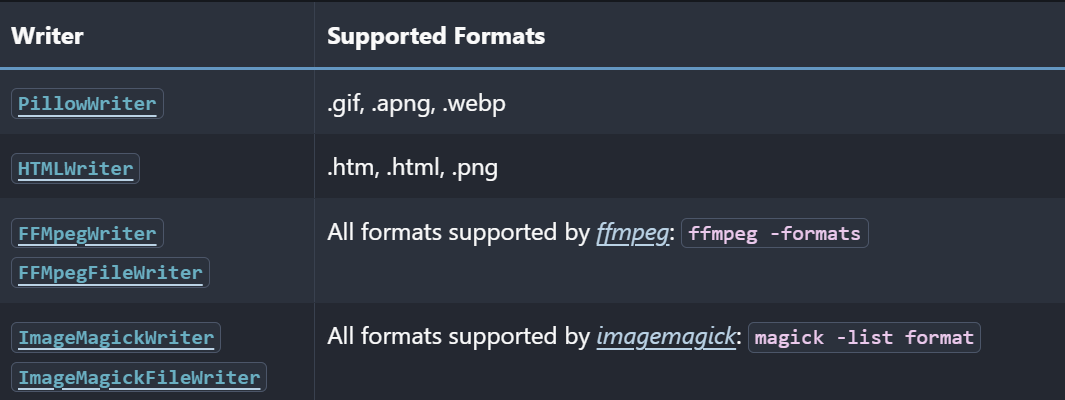

In [19]:
import matplotlib.animation as animation

ani.save(filename="/content/drive/MyDrive/Colab Notebooks/example.gif", writer="pillow")
ani.save(filename="/content/drive/MyDrive/Colab Notebooks/example.html", writer="html")